<center>
<img src="isel.png"

<h3>Licenciatura em Engenharia Informática e Multimédia</h3><br>
<br>
<h2>Processamento de Imagem e Visão</h3>
<h3>1º Trabalho Laboratorial – Contagem e Classificação de Peças de Lego Retangulares </h3>
<br>

<br>
Trabalho Realizado por:<br>

Martim Ramos - A51736<br>
Guilherme Graça - A51827<br>
Turma 51D<br><br>
Docente: Pedro Mendes Jorge <br>
<br>
26 de Outubro 2025
</center>

<center><h2>Índice</h2></center>

1. Introdução
2. Binarização e Pré-processamento das Imagens

    2.1 Histogramas das imagens
    
    2.2 Máscaras aplicadas às imagens originais
3. Melhoramento das imagens binarizadas
4. Extração de Componentes Conexos e Propriedades
5. Classificação das Peças
6. Conclusão
7. Bibliografia

<center><h2>Introdução</h2></center>

No âmbito do Trabalho Laboratorial 1 da unidade curricular, pretende-se desenvolver uma aplicação em Python capaz de realizar a contagem e classificação de peças de LEGO retangulares presentes numa imagem.
As peças encontram-se dispostas sobre uma mesa de superfície homogénea e clara, sendo captadas por uma câmara posicionada perpendicularmente ao plano de observação, de modo a minimizar distorções e facilitar o processamento da imagem.

O principal objetivo deste trabalho é promover a familiarização com as funções da biblioteca OpenCV, explorando as suas potencialidades na programação de aplicações de visão por computador em tempo real. Pretende-se, assim, aplicar técnicas fundamentais de processamento e análise de imagem, desde a leitura e pré-processamento até à segmentação e extração de propriedades geométricas dos objetos.

As peças de LEGO a considerar apresentam dimensões padronizadas, podendo pertencer a um dos seguintes tipos: 2x2, 2x4, 2x6 ou 2x8. Para o desenvolvimento e teste do algoritmo foram disponibilizadas imagens de treino pelo docente, permitindo ajustar os parâmetros e validar a fiabilidade da classificação.


De forma geral, o trabalho foi estruturado nas seguintes etapas principais:

1. Leitura das imagens fornecidas e preparação dos dados
2. Pré-processamento das imagens
3. Binarização das imagens
4. Melhoramento das imagens binarizadas
5. Extração de componentes conexos e propriedades
6. Classificação das peças

# Imports

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

<center><h2><b>Leitura das Imagens</b></h2></center>

Como ponto de partida no trabalho, para realizar a tarefa de leitura de imagens, utilizamos as bibliotecas do OpenCV para manipular as imagens e Matplotlib para a sua exibição.

Para armazenar os caminhos das imagens decidimos utilizar um array de strings, pois esta é uma estrutura de dados simples e direta para armazenar uma coleção de ficheiros. Desta forma é facil fazer iterações pelos ficheiros e é facil de alterar diretamente os caminhos da imagens. É importante notar que o folder "ImagensTreino" consta na raiz do projeto.

Tanto aqui na fase de leitura como nas seguintes tarefas, decidimos utilizar uma estrutura de grelha, com quatros colunas, para exibir todas as imagens em subplot, desta forma fica fácil de observar todas as imagens de uma vez só. Aqui fizemos o plot das imagens originais ainda sem qualquer alteração, assim ao longo do projeto poderemos voltar para ver e comparar as alterações feitas com as imagens originais.

In [2]:
import os

diretorio_alvo = 'ImagensTreino/treino'

imagens = []
imagens = [os.path.join(diretorio_alvo, f) for f in os.listdir(diretorio_alvo) if f.endswith('.jpg')]


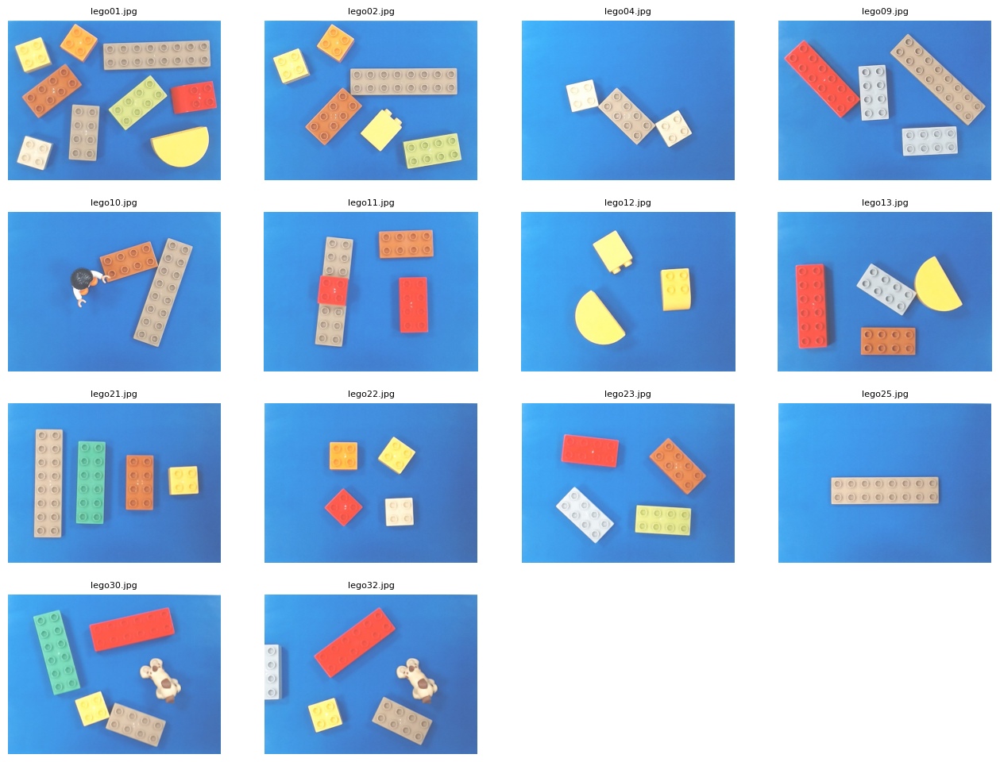

In [3]:
#Array que armazena todas as imagens de treino
#imagens = ['ImagensTreino/treino/lego01.jpg', 
#            'ImagensTreino/treino/lego02.jpg', 
#            'ImagensTreino/treino/lego04.jpg', 
#            'ImagensTreino/treino/lego09.jpg', 
#            'ImagensTreino/treino/lego10.jpg', 
#            'ImagensTreino/treino/lego11.jpg',
#            'ImagensTreino/treino/lego12.jpg',
#            'ImagensTreino/treino/lego13.jpg',
#            'ImagensTreino/treino/lego21.jpg',
#            'ImagensTreino/treino/lego22.jpg',
#            'ImagensTreino/treino/lego23.jpg',
#            'ImagensTreino/treino/lego25.jpg',
#            'ImagensTreino/treino/lego30.jpg',
#            'ImagensTreino/treino/lego32.jpg']

num = len(imagens) # Número de imagens no array
cols = 4 # Número de colunas do subplots
rows = (num + cols - 1) // cols  # Número de linhas do subplot


fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
axes = axes.flatten()

for i, path in enumerate(imagens):
    img = cv2.imread(path)

    if img is None:
        print(f"Erro ao carregar: {path}")
        axes[i].axis('off')
        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Converter BGR (formato que o OpenCV aceita)para RGB (formato que o Matplotlib aceita) 
    axes[i].imshow(img_rgb)
    axes[i].set_title(os.path.basename(path), fontsize=8)
    axes[i].axis('off')

# Esconde eixos sobrantes
for j in range(i + 1, rows*cols):
    axes[j].axis('off')

plt.show()

<center><h2><b>Binarização e Pré-processamento das Imagens</b></h2></center>
Para ter uma binarização perfeita alinhada com os objetivos do trabalho é entendido que se deve ter todos os pixeis das peças com um valor (por exemplo 255) e todo o fundo com outro valor (por exemplo 0). Visualmente as peças iriam aparecer a branco e o fundo iria aparece a preto. Ao ter esta separação clara entre o fundo e os objetos é um passo essencial para o bom funcionamento do algoritmo de extração de componentes conexos.

No inicio da fase de binarização decidimos tentar binarizar todas as imagens diretamente. Ainda sabendo que provavelmente não seria suficiente, fizemos esta binarização simples com o objetivo de obter ter informação visual que nos pudesse dar alguma dica sobre os desafios que temos de superar, como sombras, reflexos, peças de cores parecidas ao fundo...) e assim nos conseguirmos guiar nos passos seguintes.

Como estratégia inicial utilizamos o *Método de Otsu* pois foi este o método abordado nas aulas teóricas da cadeira de Processamento de Imagem e Visão, é também um método com grande capacidade de adaptação e resistente no que toca a variações de iluminação de imagem para imagem. Esta técnica faz determinação do melhor limiar/threshold a usar na binazação de forma automática tendo em conta o histograma da imagem, pois assume um pico do histograma como o fundo e outro pico como os objetos. Tendo em conta estas caracteristicas do método de otsu, podemos concluir que é um método bem superior a simplesmente escolher o valor intermédio e fixo entre 0 e 255 sendo esta a abordagem que estávamos habituados a utilizar.

Para implementar esta binarização inicial, começamos por ler cada imagem individualmente em um ciclo. 
De seguida convertemos as imagens para escala de cinzentos pois este é um passo obrigatório na binarização, cada imagem tem 3 canais de cor e para aplicar o método de otsu é necessário ter apanes um unico canal de cor em que cada pixel tem apenas o valor de intensidade (0 a 255), assim cada pixel fica apenas com a sua informação de luminancia e já é possivel calcular o limiar de otsu. Também é possivel simplesmente utilizar um dos canais de cor RGB, no entando inicialmente decidimos usar o GrayScale pois é a forma mais intuitiva e que estamos mais habituados a utilizar para reduzir de 3 para 1 canal de cor as imagens.
Após aplicar o GrayScale nas Imagens fizemos a Binarização das mesmas com o método de otsu e visualizamos os resultados.

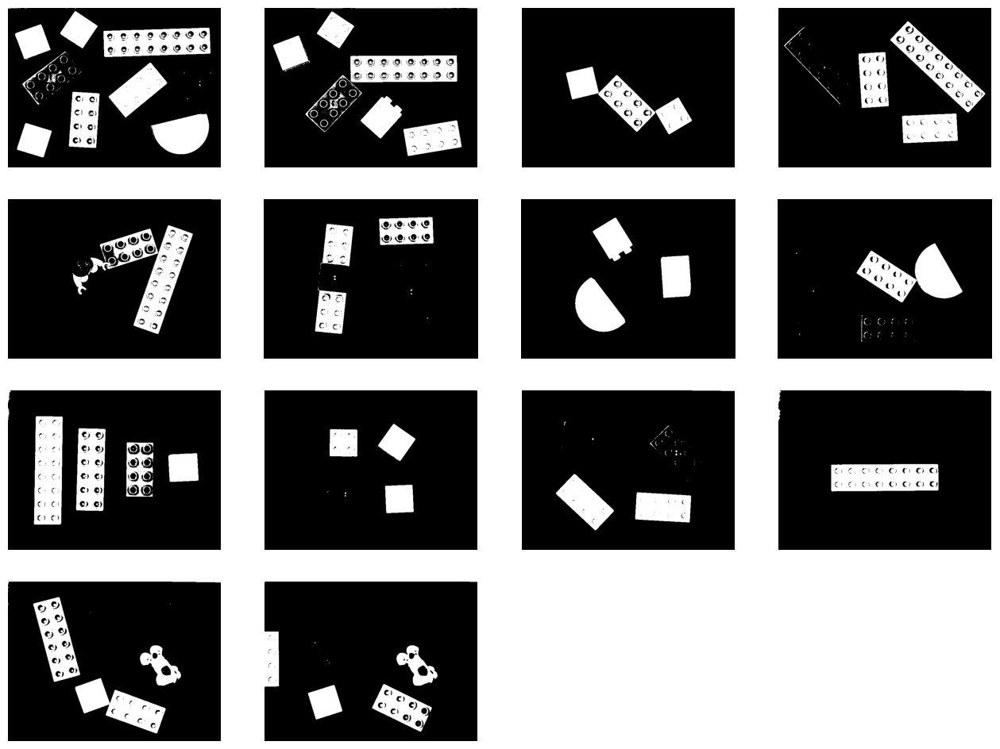

In [4]:
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows)) #num, rows e cols igual à celula de cima
axes = axes.flatten()

for i, path in enumerate(imagens):
    img = cv2.imread(path)

    if img is None:
        print(f"Erro ao carregar: {path}")

    # Converter para grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Aplicar binarização de Otsu
    _, otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU)

    # Mostrar a imagem binarizada
    axes[i].imshow(otsu, cmap='gray')
    axes[i].axis('off')

# Esconde o resto dos eixos
for j in range(i + 1, rows*cols):
    axes[j].axis('off')

plt.show()

Como podemos observar, as binarizações nao estão muito explicitas,já como esperado, pois em maior parte das imagens existe algumas peças que são confundidas com o fundo e outras que nem sequer foram detetadas no processo de binarização. Para isto teremos de aplicar algum tipo um pré-processamento nas imagens de modo a que todas as peças sejam distinguidas do fundo corretamente.

# Histogramas das imagens

Um histograma é uma representação estatística das intensidades de pixéis. Para imagens a tons de cinzento, mostra quantos pixéis há em cada nível de intensidade (0–255) e para imagens a cores, normalmente calculamos um histograma por canal (B, G, R). Visualmente é um gráfico onde o eixo horizontal são os níveis de intensidade e o eixo vertical a frequência (nº de pixéis) desses níveis.

É uma ótima ferramenta para realizar uma análise rápida das características de uma imagem mas apresenta algumas limitações como é o caso de ser pouco eficaz para cenas mais complexas mas para o nosso estudo em questão é uma ferramenta bastante útil.

Como estamos a trabalhar as imagens em formato RGB, decidmos que seria uma boa opção avaliar os histogramas de cada canal de cor de todas as imagens de treino para ver qual canal apresenta melhor contraste entre as peças e o fundo. De seguida realizamos esta operação.

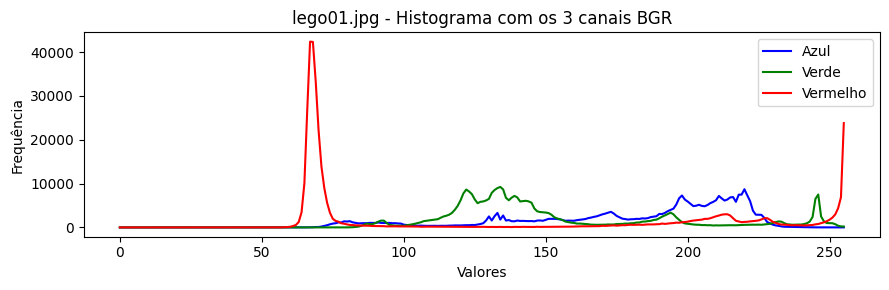

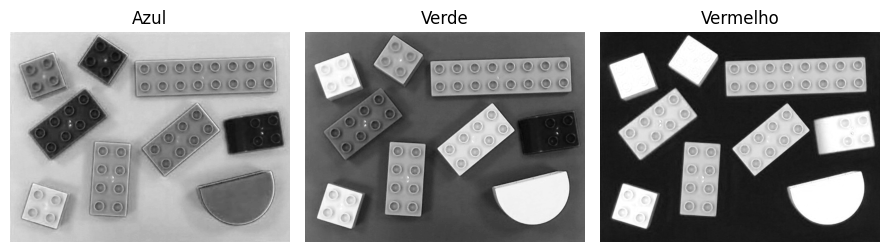

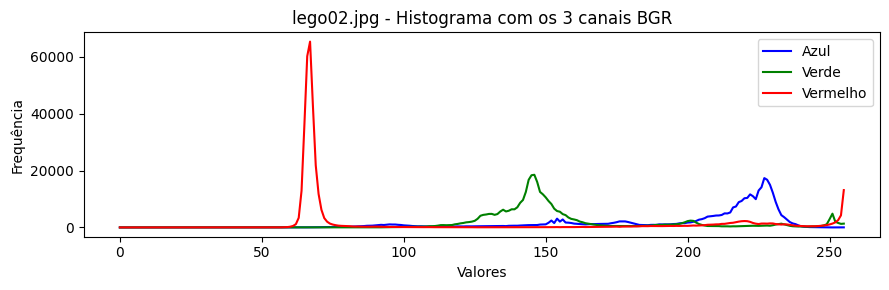

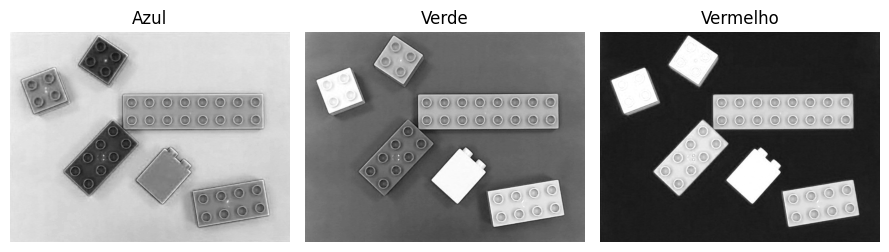

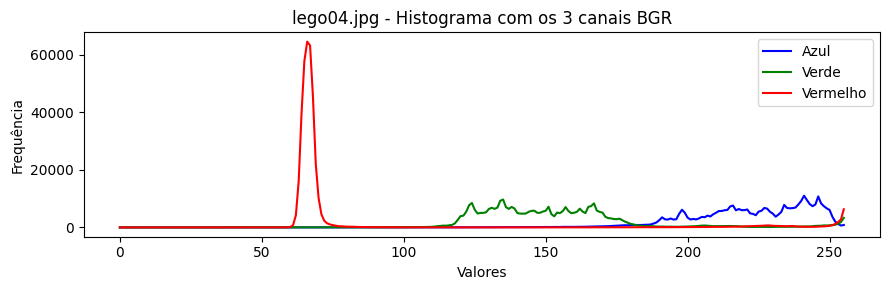

...

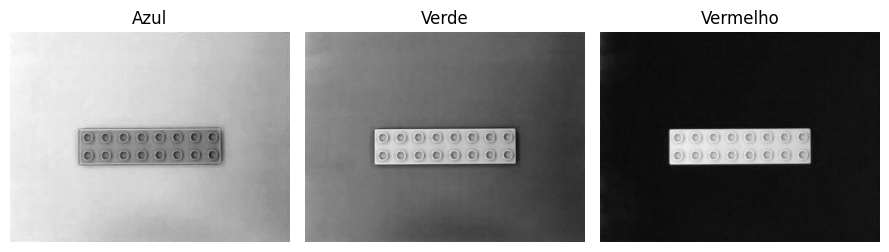

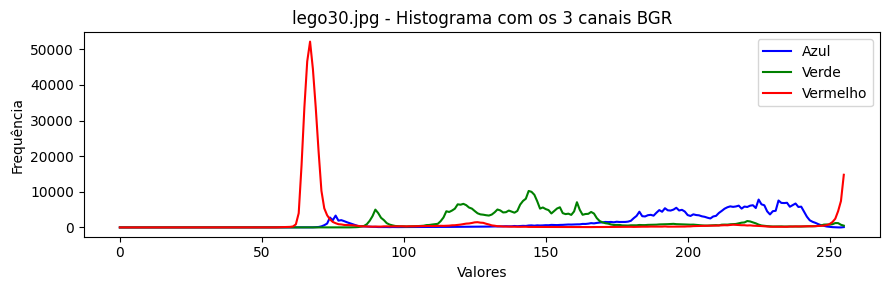

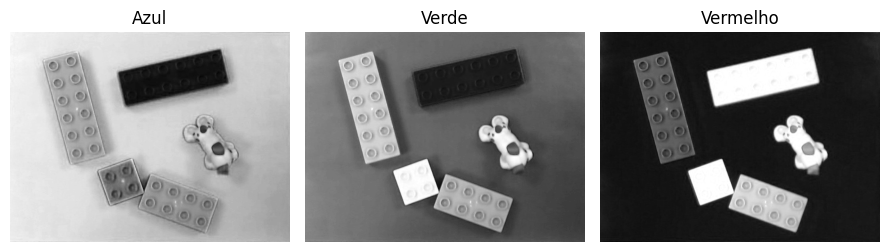

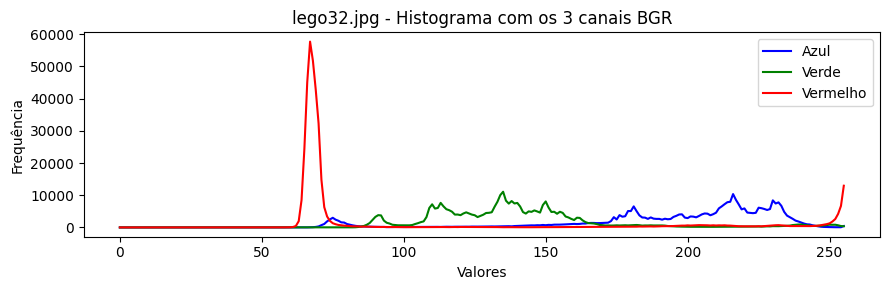

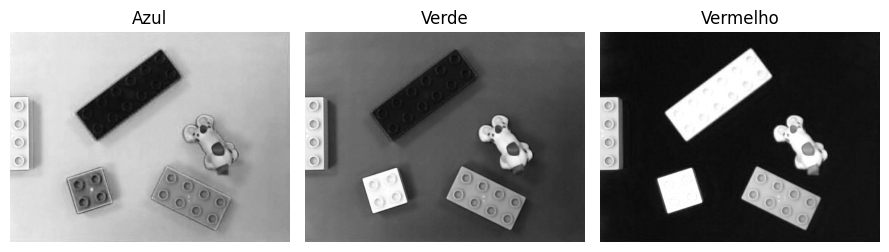

In [5]:
#TENTATIVA ATRAVÉS DO HISTOGRAMA
for path in imagens:
    img = cv2.imread(path)
    if img is None:
        print(f"Erro ao carregar: {path}")

    # Histograma de cada canal (B, G, R)
    hist_b = cv2.calcHist([img], [0], None, [256], [0, 256]).ravel()
    hist_g = cv2.calcHist([img], [1], None, [256], [0, 256]).ravel()
    hist_r = cv2.calcHist([img], [2], None, [256], [0, 256]).ravel()
    # a função ravel() achata o array 

    # Mostrar os histogramas em que cada histograma apresenta os 3 canais de cor ao mesmo tempo
    plt.figure(figsize=(9, 3))
    plt.plot(hist_b, color='b', label='Azul')
    plt.plot(hist_g, color='g', label='Verde')
    plt.plot(hist_r, color='r', label='Vermelho')
    plt.title(os.path.basename(path) + " - Histograma com os 3 canais BGR")
    plt.xlabel('Valores'); plt.ylabel('Frequência')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Visualização de cada canal em escala de cinzento
    fig, ax = plt.subplots(1, 3, figsize=(9, 3))
    ax[0].imshow(img[:, :, 0], cmap='gray'); ax[0].set_title('Azul'); ax[0].axis('off')
    ax[1].imshow(img[:, :, 1], cmap='gray'); ax[1].set_title('Verde'); ax[1].axis('off')
    ax[2].imshow(img[:, :, 2], cmap='gray'); ax[2].set_title('Vermelho'); ax[2].axis('off')
    plt.tight_layout()
    plt.show()

Através da observação dos histogramas dos três canais de cor (azul, verde e vermelho) e das respetivas imagens individuais, é possível verificar que o canal vermelho (R) apresenta o maior contraste entre as peças e o fundo. Nos canais azul e verde, as intensidades dos pixels encontram-se mais próximas entre si, o que dificulta a distinção entre os objetos e a superfície de apoio.

Este comportamento deve-se principalmente às características da iluminação e da cor do plano de fundo presente nas imagens fornecidas. Como a mesa possui uma tonalidade azulada, o canal azul (B) e o verde (G) tendem a registar valores elevados também no fundo, reduzindo o contraste. Já o canal vermelho (R), por apresentar menor resposta luminosa no fundo e maior nas peças coloridas, realça melhor os contornos e as diferenças de intensidade.~

Por essa razão, o canal vermelho foi considerado o mais adequado para segmentar as peças de LEGO e proceder à binarização na fase seguinte do processamento.

Na seguinte tentativa de binarização, recorremos novamente ao método de Otsu, mas desta vez aplicando-o exclusivamente ao canal vermelho (R) das imagens. Antes de aplicarmos a binarização, aplicámos um filtro guassiano para suavizar as imagens. Este filtro tem como função reduzir o ruído presente nas imagens, o que pode facilita imenso na tarefa de binarização.

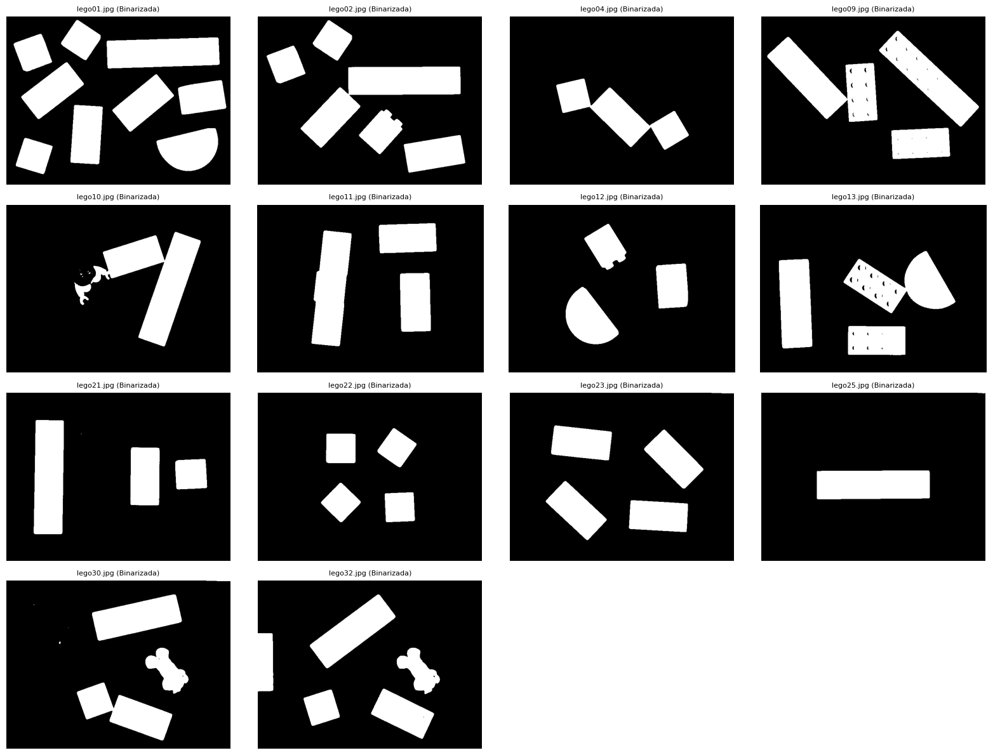

In [6]:
# Binarização com base no canal vermelho
valid_paths = []
bins = []

for path in imagens:
    img = cv2.imread(path)
    if img is None:
        print(f"Erro ao carregar: {path}")
        
            
    r = img[:, :, 2]  # Vermelho (BGR equivale ao canal 2)
    r_blur = cv2.GaussianBlur(r, (5, 5), 0) # filtro guassiano
    _, img = cv2.threshold(r_blur, 0, 255, cv2.THRESH_OTSU)

    valid_paths.append(os.path.basename(path))
    bins.append(img)


fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
axes = axes.flatten()

for i in range(num):
    axes[i].imshow(bins[i], cmap='gray')
    axes[i].set_title(f"{valid_paths[i]} (Binarizada)", fontsize=8)
    axes[i].axis('off')
for j in range(i + 1, rows * cols):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Podemos observar que as imagens binarizadas jão estão melhores que as imagens da primeiro tentativa de binarização mas ainda assim reparámos que, em específico, nas imagens "lego21.jpg" e "lego30.jpg" existe uma peça em ambas que não está a ser binarizada corretamente. Isto signfica que o nosso processo de pré-processamento não pode ficar por aqui, teremos que arranjar uma forma de estas peças ficarem totalmente visiveis após o processo de binarazação.

Após pensarmos no assunto decidimos que a melhor opção seria mesmo "manusear" a cor destas peças, pois percebemos rapidamente que, nas imagens originais estas peças eram esverdeadas o que fica suscetível a erros inesperados na binarização pois a cor destas peças assemelha-se muito à cor do fundo. Ou seja, o que o que acontece na binarização é que todas os pixeis que estão abaixo do limiar de otsu são convertidos para 0 (preto) e todos os pixeis acima do limiar são convertidos para 255 (branco). Como as peças esverdeadas têm uma cor muito parecida com o fundo, muitos dos pixeis destas peças acabam por ficar abaixo do limiar e são convertidos para preto, fazendo com que estas peças não sejam detetadas corretamente.

# Máscara aplicada às imagens originais

Decidimos criar umas máscara que respeite um determinado limiar de cores, ou seja, vamos definir um intervalo de cores que consideramos ser o intervalo de cores das peças esverdeadas e vamos alterar a cor dessas peças para uma cor que se destaque mais do fundo, neste caso decidimos alterar a cor dessas peças para vermelho. A escolha do vermelho deve-se ao facto de termos percebido atráves da tentiva de binarização que as peças no canal vermelho são as que apresentam melhor contraste com o fundo. Faz-nos sentido converter para esta cor porrque possui na componente (red) um valor alto (255) e nas outras componentes (green e blue) valores baixos (0), o que faz com que estas peças (a vermelho) se destaquem bastante do fundo azul claro.

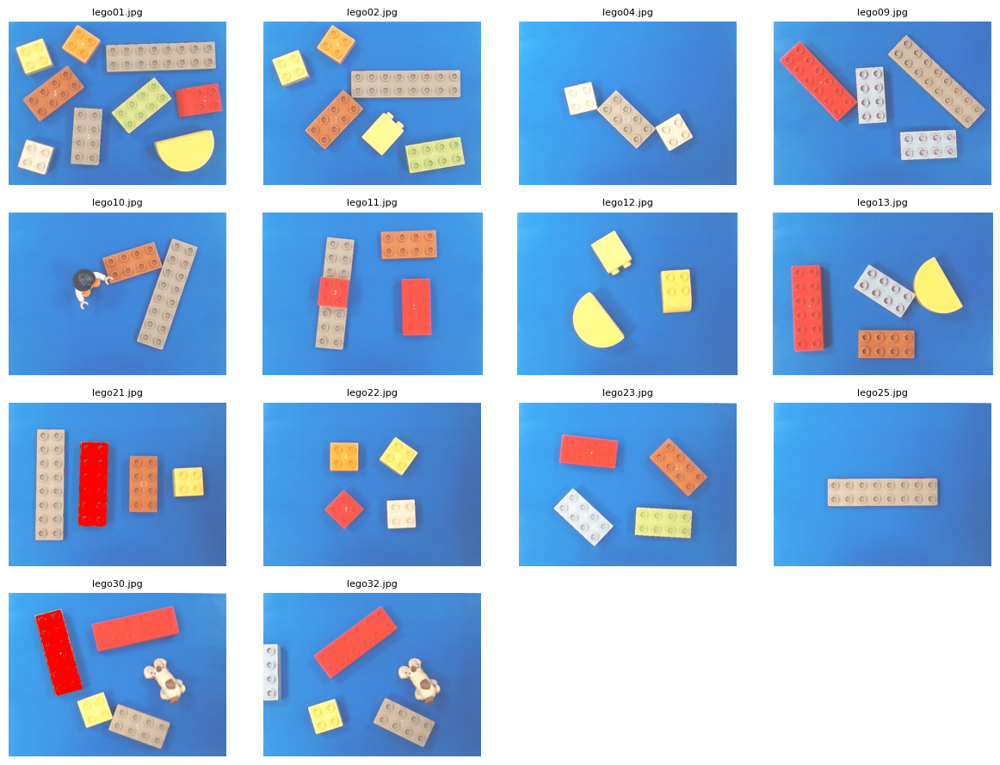

In [7]:
imagens_alteradas = [] # neste array serão guardadas as imagens com todas as peças inclusivé as esverdeadas alteradas para vermelho

# Intervalo RGB das peças esverdeadas 
corMin = np.array([60, 170, 140])
corMax = np.array([170, 240, 210])

for path in imagens:
    bgr = cv2.imread(path)
    if bgr is None:
        print(f"Erro ao carregar: {path}")
        continue

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    # criar a máscara com os valores dentro do limiar criado
    mask  = cv2.inRange(rgb, corMin, corMax)

    # Recoloração para vermelho sólido
    rgb[mask != 0] = [255, 0, 0]

    imagens_alteradas.append(cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR))

# Mostrar
plt.figure(figsize=(12, 9))

for i, img_bgr in enumerate(imagens_alteradas):
    plt.subplot(rows, cols, i+1)
    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    plt.title(os.path.basename(imagens[i]), fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()

O intervalo de cores para as peças esverdeadas foi obtido com recurso a uma ferramenta de identificação de cores. Esta ferramenta está disponível na web através do link: https://imagecolorpicker.com/ . Com esta ferramenta conseguimos achar uma base sólida em valores de RGB para definir o intervalo de cores que queremos alterar, depois fomos refinando os valores até obter o resultado desejado.

Em anexo fica uma imagem que demonstra o uso que realizamos nesta ferramenta.

<img src="imagem_processo_extracao_cor_pixeis.jpg" width="500">

Depois de termos finalemente um conjunto de imagens que achamos prontas a serem binarizadas corretamente, decidimos avançar para a fase de binarização final. Nesta fase decidimos manter a estratégia que já tínhamos utilizado anteriormente, ou seja, vamos continuar a utilizar o canal vermelho (R) para realizar a binarização, pois como já foi referido anteriormente este canal apresenta o melhor contraste entre as peças e o fundo.

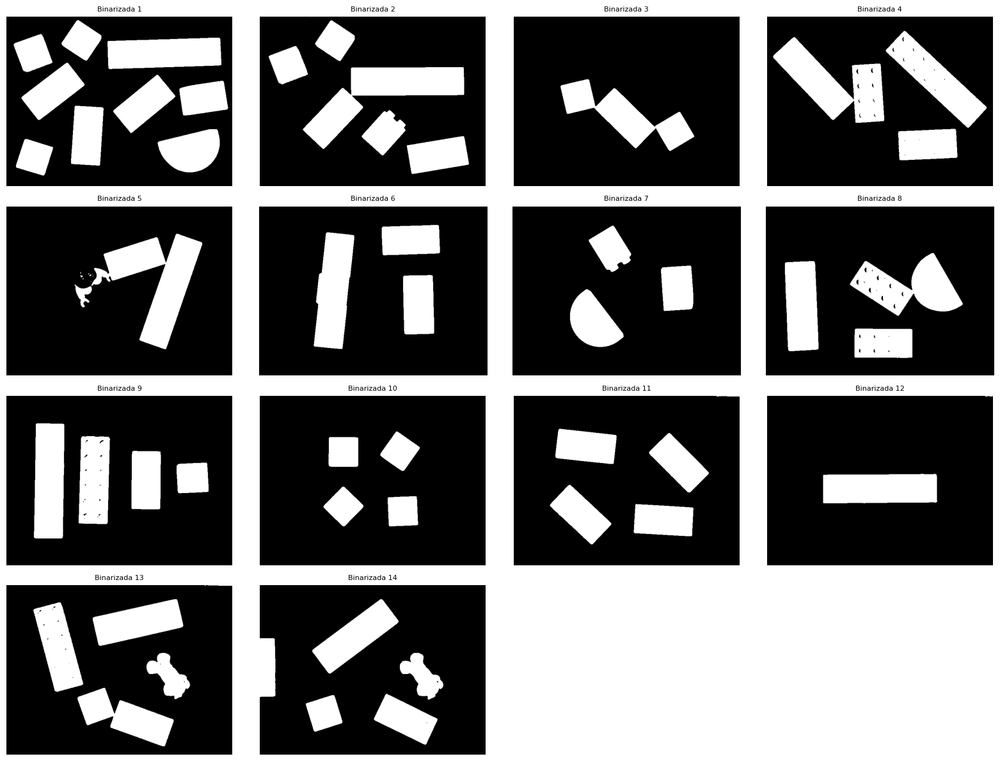

In [8]:
#Agora vamos tentar binarizar novamente mas utilizando o array que nele tem contidas as imagens com as peças mais esveradas alteradas para vermelho
imagens_alteradas_binarizadas = []

for img_bgr in imagens_alteradas:
    r = img_bgr[:, :, 2] # canal vermelho
    r_blur = cv2.GaussianBlur(r, (5, 5), 0) # suavização usando um filtro Gaussiano 
    _, img = cv2.threshold(r_blur, 0, 255, cv2.THRESH_OTSU) # Usamos o método de Otsu novamente
    imagens_alteradas_binarizadas.append(img)

# Mostrar resultados
plt.figure(figsize=(4*cols, 3*rows))
for i, b in enumerate(imagens_alteradas_binarizadas):
    plt.subplot(rows, cols, i+1)
    plt.imshow(b, cmap='gray')
    plt.title(f"Binarizada {i+1}", fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()

Podemos observar que após este processo de alteração de cor das peças esverdeadas para vermelhas, a binarização já está quase perfeita em todas as imagens de treino. De seguida podemos avançar para o processo de melhoramento das imagens obtidas, de modo a que as peças fiquem bem definidas e realçadas para o processo de extração de componentes conexos e devidas propriedades. Para isso iremos usar operadores morfológicos de modo a preencher pequenos buracos que possam existir. Teremos também de ter em conta a separação de peças que possam estar ligadas (usar a função de erode e posteriormente o dilate).

<center><h2><b>Melhoramento das Imagens Binarizadas</b></h2></center>

De seguida vamos recorrer aos métodos getStructuringElement, morphologyEx, erode e dilate da biblioteca OpenCV para realizar um melhoramento das imagens binarizadas.

Como primeiro passo, definimos três elementos estruturantes (kernels) que serão utilizados nas operações morfológicas. Optamos por um kernel elítico de tamanho 7x7, que é eficaz para eliminar pequenos ruídos e preencher buracos nas peças (pois algumas peças apresentavam ainda o formato das suas cabeças arredondadas daí termos escolhido um kernel elítico mas que na verdade é circular pois usamos os mesmo valores em ambos os parâmetros do kernel), por um kernel retangular grande e outro mais pequeno. O grande tem como objetivo erodir fortemente nos cantos, pois maior parte das peças estavam juntas pelos cantos daí a nossa ideia de usar um kernel de forma retangular. O mais pequeno foi usado na dilatação das peças pois após a erosão das mesmas, estas perdem o formato original então o dilate ajuda a recuperar esse formato perdido.

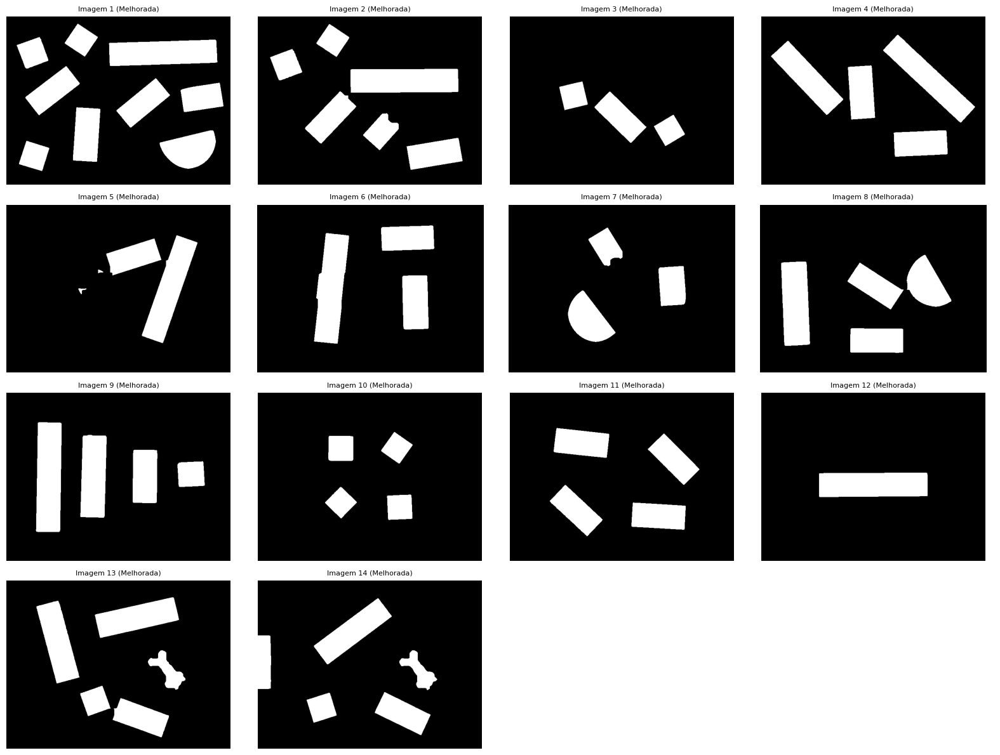

In [9]:
#Elemento estruturante
kernelCLOSE = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7)) #Elipse médio - mais adequado para curvas
kernelERODE = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17)) #rectangulo grande
kernelDILATE = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3)) #rectangulo pequeno


imagens_melhoradas = [] # neste array serão guardadas as imagens binarizadas com as melhorias morfológicas aplicadas
for img in imagens_alteradas_binarizadas:
    morph = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernelCLOSE)  # fecha buracos pequenos
    morph = cv2.erode(morph, kernelERODE) # separa peças coladas
    morph = cv2.dilate(morph, kernelDILATE) # recupera formato original
    imagens_melhoradas.append(morph)

# Mostrar resultados
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
axes = axes.flatten()

for i in range(len(imagens_melhoradas)):
    axes[i].imshow(imagens_melhoradas[i], cmap='gray')
    axes[i].set_title(f"Imagem {i+1} (Melhorada)", fontsize=8)
    axes[i].axis('off')
for j in range(i + 1, rows * cols):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Após a aplicação dos operadores morfológicos, podemos observar que as peças estão bem definidas e separadas bem como áreas que antes tinham alguns buracos abertos já se apresentam todos fechados, o que nos permite avançar para o processo de extração de componentes conexos e devidas propriedades das peças de LEGO.

<center><h2><b>Extração de Componentes Conexos e Propriedades</h2></b></center>

Após a binarização e melhoramento das imagens, nesta fase temos várias imagens melhoradas que contêm as peças totalmente a branco e desconectadas umas das outras. Como objetivo desta fase, cabe a nós encontrar uma forma de identificar e isolar cada peça individual/componente conexo e analisar as suas características de modo a posteriormente conseguir fazer a identificação das peças.

O desenvolvimento desta fase foi um processo iterativo em que a nossa estratégia foi ajustada e evoluiu à medida que iam surgindo desafios e limitações nas abordagens anteriores.

Inicialmente a nossa abordagem seria relativamente simples. Nós pretendíamos:
 - Encontrar todos os contornos com *cv2.findContours*
 - Para cada contorno verificar se é um rectangulo através da função desenvolvida *isRectangle*
 - Se o contorno for um rectangulo então extraiamos a sua area com o *cv2.contourArea*
A nossa hipótese era que depois de extrair as áreas, iríamos definir ranges de área para cada tipo peça de peça e posteriormente usar essas áreas  para a classificação. Utilizamos o *cv2.putText* para imprimir esses valores de cada peça para conseguirmos recolher esses dados para depois definir essas gamas/ranges de valores.

Após analisar os resultados da nossa primeira abordagem visualmente, deparamos-nos com o primeiro problema:
As peças que estavam incompletas por terem sido recordadas da imagem poderiam ser classificadas como retângulos e isso iria gerar uma área e classificação incorreta. Em específico, na imagem 14 existe uma peça 2x4 que está cortada mesmo a meio, logo a sua área é metade e iria depois ser classificada como uma peça 2x2 quando ela deveria simplesmente ser identificada.
Para solucionar este problema implementamos a verificação "toca_borda" no inicio do ciclo de análise de cada contorno, esta verificação usa *cv2.boundingRect* para obter a caixa que envolve cada componente conexo e se essa caixa tocar em qualquer uma das bordas da imagem então o ciclo passa diretamente para o proximo componente.

Após filtrar as peças cortadas, surgiu um segundo problema, existe alguma ambiguidade em usar apenas a área para verificar o tipo das peças pois pode haver falsos positivos, verificamos que algumas peças tinham contornos retangulares mas que não são peças elegíveis para o nosso trabalho. Assim sendo, decidimos que para além da área, também iríamos extrair altura de cada contorno de modo a podermos fazer uma filtragem mais eficaz das peças que realmente nos interessam. Não utilizamos a largura pois estamos a tratar de peças 2xN portanto a largura dos contornos será praticamente a mesma.

Para fazer a análise das propriedades dos componentes conexos, definimos parâmetros globais
que controlam o quão restrito é a definição do componente ser um retângulo ou não:
- *EPSILON_FACTOR* - Este fator é utilizado quando se faz a aproximação polignal dos contornos (*cv2.aproxPolyDP*). Para este fator utilizamos um valor de 0.02, ou seja 2% do perimetro, escolhemos este valor por ter um bom equilíbrio na medida que suaviza as irregularidas nas bordas das peças mas não distorce a sua forma retangular geral. Notamos que ao aumentar para mais este valor iria simplificar demais a forma dos contornos, logo peças que são mais diferentes de retângulos passam a ser consideradas como retângulos.
- *TOLERANCIA_ANGULO* - Esta variável define a tolerância em graus para que um ângulo interno do retângulo seja considerado como um angulo reto. Escolhemos 15 graus para dar alguma flexibilidade, assim os angulos não necessitam ter exatamente 90 graus, basta andarem perto desse valor.

O Processo de análise foi dividido num ciclo principal que usa o *cv2.findContours()* para rastrear a borda/contorno de cada compotente conexo da imagem e cada um destes contornos é analisado ao chamar a função auxiliar:

- *isRectangle(contorno)*  - esta função é a principal que recebe um contorno e retorna um boleano que indica se ele é um retângulo e indica tambem a sua área e altura.
  - Para determinar se é um retângulo é usado o *cv2.approxPolyDP* pois depois da binarizar a imagem o seu contorno nunca é perfeito, há sempre algumas irregularidades, ao usar esta função podemos simplificar para uma forma polignal mais simples e extrair o numero de vertices. Depois os vertices são ordenados para saber quais são vizinhos uns dos outros através do seu ângulo relativamente ao centro, fazemos isto para descobrir os ângulos internos dos retângulos ao utilizar outra função auxiliar *calcularAngulo(p0,p1,p2)* que implementa a fórmula matemática do ângulo entre dois vetores. Depois de sabermos os ângulos internos basta verificar se estes ângulos são próximos que chegue de 90 graus e se forem então são retângulos.
  - Para calcular a área é usado o *cv2.contourArea(contorno)* que devolve diretamente a área do componente conexo.
  - Para extrair a altura utilizamos primeiro o método *cv2.minAreaRect(contorno)* para extrair as dimensões, usamos este em oposição ao *cv2.boundingRect* pois os retângulos podem estar rodados. o minAreaRect devolve o retângulo de área mínima que envolve o contorno, depois extraimos o tuplo que contém as dimensões (altura e largura) do retângulo e verificamos qual delas é maior pois sabemos que todas as peças são 2xN e que a menor peça é 2x2, logo a altura é sempre o maior valor destas dimensões (para as peças 2x2 a altura é igual).

Para visualizar e armazenar os resultados, usamos o *cv2.drawContours* que desenha as bordas dos componentes conexos. Usamos *cv2.moments* para calcular o centro dos retângulos, este é o metodo mais acertado para descubrir o centro porque por exemplo se usarmos o boundingRect com os parametros x + width/2, y + height/2 iriamos ter o centro da caixa que envolve o retângulos, não iria funcionar muito bem para os retângulos que estão rodados, já o moments descobre o centro de massa da peça. Usamos esse centro para colocar o texto com a area e a altura do retângulo com o *cv2.putText*. 

Por fim conseguimos visualizar o resultado da extração dos componentes e das propriedades ao ver na imagens da grelha contornado a preto os componentes conexos classificados como retângulos e contornado a verde os componentes que não passaram nessa na verificação.

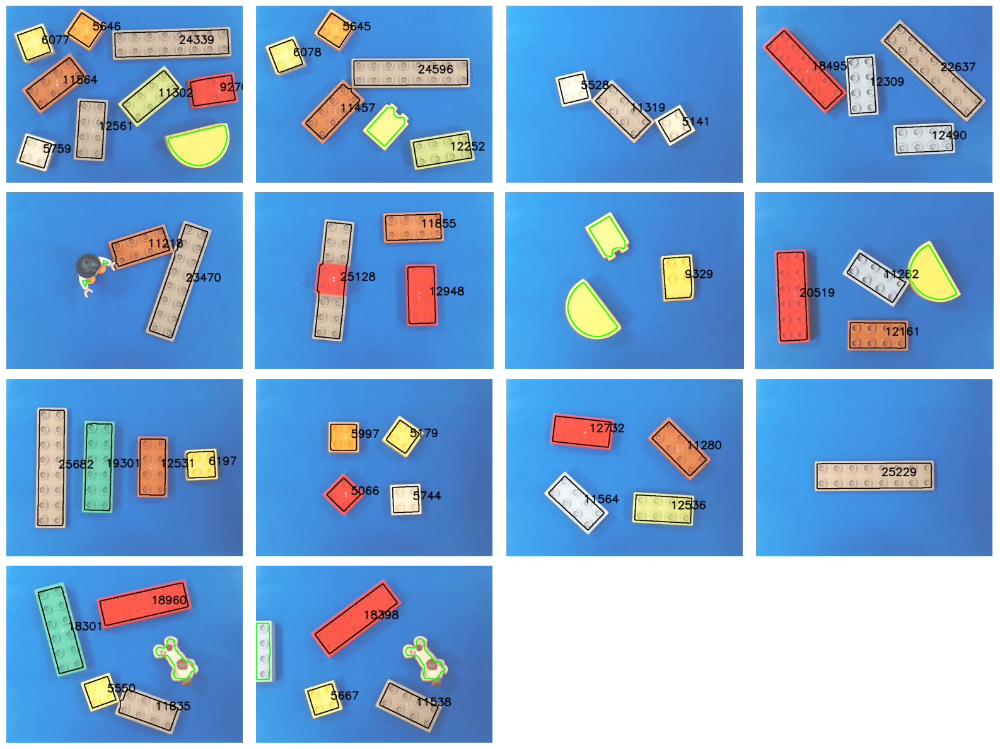

In [10]:
EPSILON_FACTOR = 0.02          # epsilon relativo ao perímetro para approxPolyDP
#quanto maior o fator, mais simples fica o poligno
TOLERANCIA_ANGULO = 15             # tolerância em graus para ângulos cerca de 90º
TEXT_COLOR = (0, 0, 0)       # preto para contornos retangulares
CONTOUR_COLOR = (0, 255, 0)    # verde para outros contornos
TEXT_FONT = cv2.FONT_HERSHEY_SIMPLEX

def calcularAngulo(p0, p1, p2):
        #p1 é o vertice atual
        #p0 vai ser o ponto anterior vizinho
        #p2 vai ser o ponto seguinte vizinho

        #calcula vetores de p1 para os vizinhos
        v1 = p0 - p1
        v2 = p2 - p1
        #comprimentos dos vetores(norma)
        n1 = np.linalg.norm(v1)
        n2 = np.linalg.norm(v2)
        
        #se for 0 os pontos estão no mesmo sitio
        if n1 == 0 or n2 == 0:
            return 0.0

        #formula do angulo entre dois vetores:
        #cos(teta) = (v1 . v2) / (||v1|| * ||v2||), logo
        #teta =arccos( (v1 . v2) / (||v1|| * ||v2||) )
        angulo = np.arccos(np.dot(v1, v2) / (n1 * n2))
        return np.degrees(angulo)

def isRectangle(contorno):
    area = cv2.contourArea(contorno) # calcula área do contorno
    
    perimetro = cv2.arcLength(contorno, True) # calcula o perímetro do contorno
    epsilon = EPSILON_FACTOR * perimetro # epsilon para approxPolyDP
    approx = cv2.approxPolyDP(contorno, epsilon, True) # aproximação do contorno
    if len(approx) != 4: # verifica se tem 4 vértices
        return False, area , 0.0

    # calcular ângulos em cada vértice em relação ao centro
    pontos = approx.reshape(4, 2) # pontos 2D, cordenadas dos pontos em cada linha

    #Descubrir o angulo entre os pontos em relação ao centro
    #com o objetivo de ordenar os pontos de forma a que estejam um ao lado do outro
    
    # ordenar os pontos pela direção angular em torno do centróide
    centro = pontos.mean(axis=0) #ponto central entre os pontos
    #Aqui para encontrar o centro tambem podiamos ter usado o moments mas como já tinhamos os vertices era mais
    #direto calcular logo a média
    
    angles = np.arctan2(pontos[:, 1] - centro[1], pontos[:, 0] - centro[0])
    #diferenças em y e diferenças em x
    #calcula o angulo para cada ponto
    order = np.argsort(angles)  #ordena no sentido contrario dos ponteiros do relogio
    #argsort - ordena os indices
    pontos_ordenados = pontos[order]

    # verificar ângulos ~90º
    for i in range(4):
        p1 = pontos_ordenados[i]              # O VÉRTICE atual
        p0 = pontos_ordenados[(i - 1) % 4]    # O ponto ANTERIOR (vizinho)
        p2 = pontos_ordenados[(i + 1) % 4]    # O ponto SEGUINTE (vizinho)
        
        a = calcularAngulo(p0, p1, p2)
        if abs(a - 90.0) > TOLERANCIA_ANGULO:
            return False, area, 0.0
            
    rect = cv2.minAreaRect(contorno)     # Obtém o retângulo de área mínima
    dims = rect[1]                      # dims é uma tupla (dim1, dim2)
    altura = max(dims)
    #lado mais comprido é a altura
    return True, area, altura

# verifica existência das listas esperadas
imagens_bin = imagens_melhoradas        

imagens_classificadas = [] # array que guarda as imagens com os contornos desenhados por cima

for i, img in enumerate(imagens_melhoradas):

    h_img, w_img = img.shape
    #num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(img, connectivity=8)
    
    # Encontrar os componentes conexos dos contornos
    contornos, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # As imagens originais são usadas como base desenhar os contornos por cima
    base = cv2.imread(imagens[i])
    if base is None:
        print(f"Erro ao carregar: {imagens[i]}")

    # desenhar(contornos a preto para as peças que sejam retângulos, outros a verde para as peças que não são)
    for contorno in contornos:
        # Obtém a caixa envolvente (axis-aligned) do contorno
        x, y, w, h = cv2.boundingRect(contorno)
        
        # Define uma pequena tolerância de borda (ex: 2 pixels)
        tolerancia_borda = 2
        
        # Verifica se a caixa toca em qualquer uma das 4 bordas da imagem
        toca_borda = (x <= tolerancia_borda or 
                      y <= tolerancia_borda or 
                      (x + w) >= (w_img - tolerancia_borda) or 
                      (y + h) >= (h_img - tolerancia_borda))
        
        if toca_borda:
            # Peça está cortada (como a 8721). Marca a verde e ignora.
            cv2.drawContours(base, [contorno], -1, CONTOUR_COLOR, 2)
            continue # Salta para o próximo contorno
        
        is_rect, area, altura = isRectangle(contorno) # verifica se o contorno é retangular

        if is_rect: # se for retângulo
            cv2.drawContours(base, [contorno], -1, TEXT_COLOR, 2) # desenha o contorno

            M = cv2.moments(contorno) # momentos do contorno para calcular o centróide 
            if M['m00'] != 0: # se a área do contorno for diferente de zero
                #m00, o momento 0 é a massa total (soma de todos os pixeis)
                #m10, momento 1 em x, massa distribuida no eixo x
                #m01, momento 1 em y, massa distribuida no eixo y
                cx = int(M['m10'] / M['m00']) #cord x do centro = momento total em x/ massa total
                cy = int(M['m01'] / M['m00']) 
                text_pos = (cx + 5, cy) # posição do texto ao lado do centróide
            else:
                x, y, bw, bh = cv2.boundingRect(contorno)
                
                text_pos = (x, max(0, y-5)) # posição do texto acima do retângulo


            h, w = img.shape # obter dimensões das imagens
            font_scale = max(0.4, min(w, h) / 500.0) # tamanho da fonte adaptado ao tamanho da imagem
            #cv2.putText(base, f" {int(altura)}", text_pos, TEXT_FONT, font_scale, TEXT_COLOR, 2, cv2.LINE_AA) #IMPRIME SOMENTE A ALTURA PARA FINS DE TESTE
            cv2.putText(base, f" {int(area)}", text_pos, TEXT_FONT, font_scale, TEXT_COLOR, 2, cv2.LINE_AA) # IMPRIME SOMENTE A AREA PARA FINS DE TESTE
            #cv2.putText(base, f"{int(area)} | {int(altura)}", text_pos, TEXT_FONT, font_scale, TEXT_COLOR, 2, cv2.LINE_AA)            

        else: # se nao for um retângulo, significa que será uma peça não identificada
            cv2.drawContours(base, [contorno], -1, CONTOUR_COLOR, 2) # desenha o contorno a verde para este tipo de peças

    imagens_classificadas.append(base) # adicionar a imagem com contornos ao array criado

# Mostrar imagens
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
axes = axes.flatten()
for ax in axes: ax.axis('off')
for i, img in enumerate(imagens_classificadas):
    axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.tight_layout()
plt.show()

Após realizada a extração de componentes conexos e respetivas propriedades, ainda temos algumas peças que têm uma superfície redonda que não deve ser considerada uma peça válida mas a seguir quando realizarmos o classificador vamos fazer com que ela deixe de ser considerada uma peça válida, atráves dos ranges utilizados das alturas e áreas.

De seguida podemos avançar para o processo de classificação das peças.

<center><h2><b>Classificação das Peças</h2></b></center>

Antes de passarmos à implementação do classificador, precisamos de guardar as áreas e alturas de todos os tipos de peças que temos no conjunto das imagens de treino. Para isso vamos armazenar manualmente as alturas e as áreas em arrays para cada tipo de dimensão de peça. Os valores extraídos para os devidos arrays foram obtidos com base no output acima dos componentes conexos e propriedades.

Para depois podermos realizar o classificador, precisamos de armazenar os valores máximos e mínimos de cada array de alturas e áreas. Serão estes valores que irão definir os ranges que iremos utilizar no classificador para cada tipo de peça. 

In [11]:
#Arrays para guardar as alturas dos varios tipo de peça

# Todos os valores presentes nos arrays estão expressos em píxeis

# Definimos uma tolerância para os valores máximos e mínimos para o caso das imagens de teste que o docente fornecerá poderem dar alguns valores de área e altura diferentes dos valores de treino
TOLERANCIA = 5

altura_2x2 = [81,77,80,75,72,82,78,74,76]
altura_2x4 = [162, 164, 168, 169, 166, 162, 165, 163,167, 160,171]
altura_2x6 = [256, 261, 259, 251, 254, 255]
altura_2x8 = [339, 335,340, 336, 345, 341] 

# Calcular e guardar o max e min para 2x2
max_altura_2x2 = max(altura_2x2) + TOLERANCIA
min_altura_2x2 = min(altura_2x2) - TOLERANCIA

# Calcular e guardar o max e min para 2x4
max_altura_2x4 = max(altura_2x4) + TOLERANCIA
min_altura_2x4 = min(altura_2x4) - TOLERANCIA

# Calcular e guardar o max e min para 2x6
max_altura_2x6 = max(altura_2x6) + TOLERANCIA
min_altura_2x6 = min(altura_2x6) - TOLERANCIA

# Calcular e guardar o max e min para 2x8
max_altura_2x8 = max(altura_2x8) + TOLERANCIA
min_altura_2x8 = min(altura_2x8) - TOLERANCIA

print("Valores das Alturas:")
print(f"Peça 2x2: Min={min_altura_2x2}, Max={max_altura_2x2}")
print(f"Peça 2x4: Min={min_altura_2x4}, Max={max_altura_2x4}")
print(f"Peça 2x6: Min={min_altura_2x6}, Max={max_altura_2x6}")
print(f"Peça 2x8: Min={min_altura_2x8}, Max={max_altura_2x8}")

#Arrays para guardar as areas dos varios tipo de peça
area_2x2 = [6077, 5646, 5759, 6078, 5645, 5528, 5141, 6197, 5997, 5179, 5066, 5744, 5550, 5667]
area_2x4 = [11564, 11302, 12561, 11457, 12252, 11319, 12309, 12490, 12948, 11218, 11855, 11262, 12161, 12531, 12732, 11280, 11564, 12536, 11835, 11538]
area_2x6 = [18495,20519, 19301, 18301, 18398]
area_2x8 = [24339, 24596, 22637, 23470,25128, 25682, 25229]

# Calcular e guardar o max e min para 2x2
max_area_2x2 = max(area_2x2) + TOLERANCIA
min_area_2x2 = min(area_2x2) - TOLERANCIA

# Calcular e guardar o max e min para 2x4
max_area_2x4 = max(area_2x4) + TOLERANCIA
min_area_2x4 = min(area_2x4) - TOLERANCIA

# Calcular e guardar o max e min para 2x6
max_area_2x6 = max(area_2x6) + TOLERANCIA
min_area_2x6 = min(area_2x6) - TOLERANCIA

# Calcular e guardar o max e min para 2x8
max_area_2x8 = max(area_2x8) + TOLERANCIA
min_area_2x8 = min(area_2x8) - TOLERANCIA

print("\nValores das Áreas:")
print(f"Peça 2x2: Min={min_area_2x2}, Max={max_area_2x2}")
print(f"Peça 2x4: Min={min_area_2x4}, Max={max_area_2x4}")
print(f"Peça 2x6: Min={min_area_2x6}, Max={max_area_2x6}")
print(f"Peça 2x8: Min={min_area_2x8}, Max={max_area_2x8}")

Valores das Alturas:
Peça 2x2: Min=67, Max=87
Peça 2x4: Min=155, Max=176
Peça 2x6: Min=246, Max=266
Peça 2x8: Min=330, Max=350

Valores das Áreas:
Peça 2x2: Min=5061, Max=6202
Peça 2x4: Min=11213, Max=12953
Peça 2x6: Min=18296, Max=20524
Peça 2x8: Min=22632, Max=25687


Com os valores máximos e mínimos definidos, podemos avançar para a implementação do classificador. A lógica do classificador é simples: para cada peça detetada válida, verificamos se a sua altura e área estão dentro dos ranges definidos para cada tipo de peça (2x2, 2x4, 2x6, 2x8). Se ambos os valores estiverem dentro do range correspondente, classificamos a peça como sendo desse tipo. Caso não seja identificada uma peça válida, etiquetamos essa peça como "Indefinida". 

Na fase de rotulação das peças, optamos por calcular novamente o centroide de cada peça para posicionar a etiqueta de classificação. Esta abordagem permite que a etiqueta seja colocada de forma mais centralizada e visível, especialmente em peças que podem ter formatos irregulares ou estarem inclinadas. 
Colocamos também um rótulo de informação no canto superior esquerdo da imagem final, indicando o número total de cada tipo de peças detetadas.

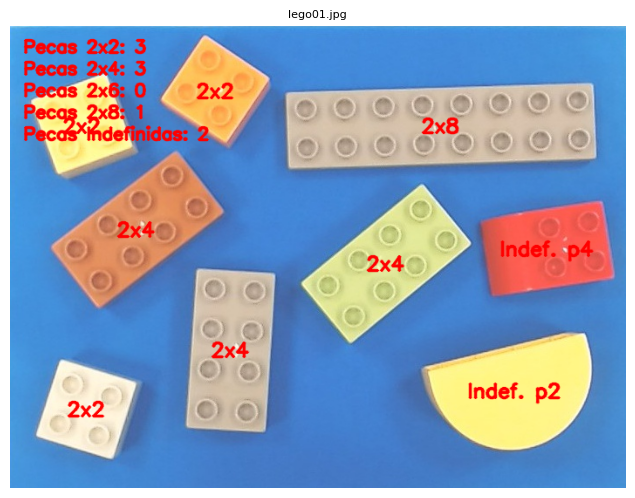

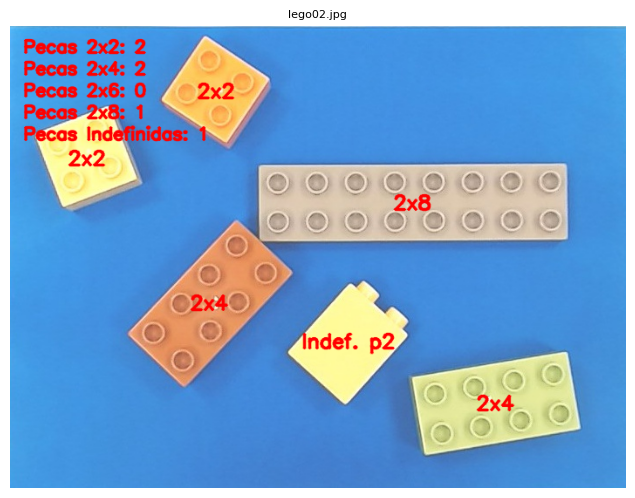

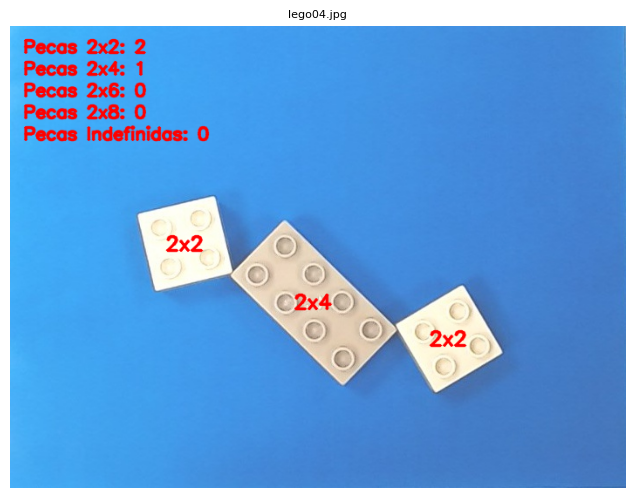

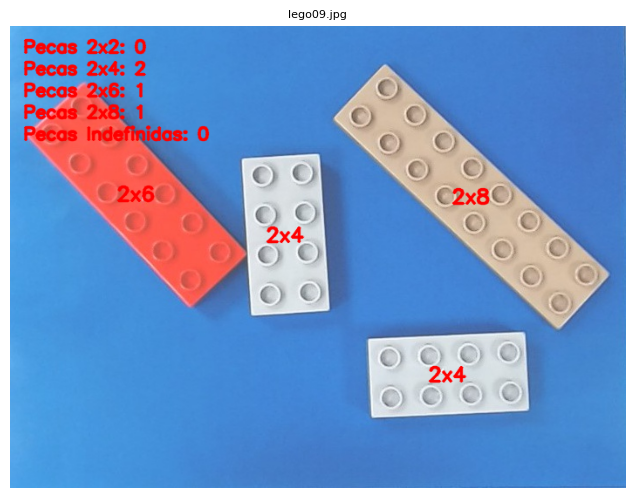

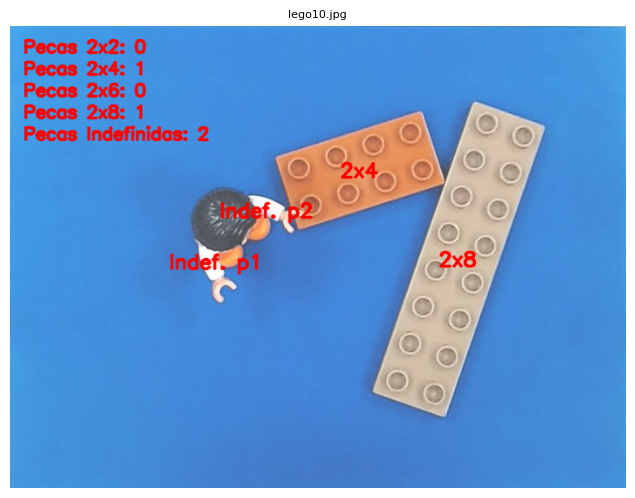

...

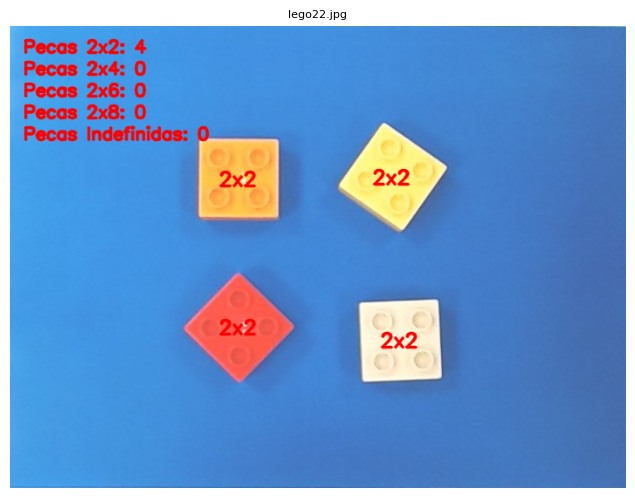

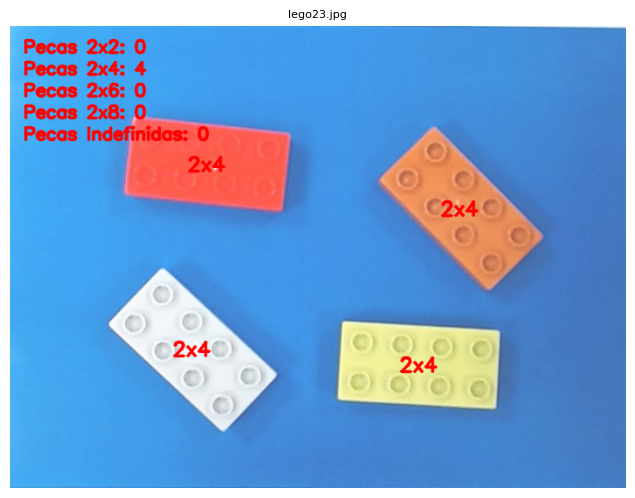

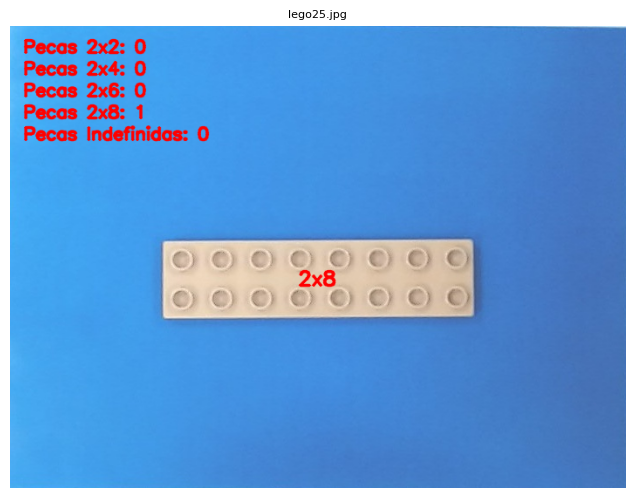

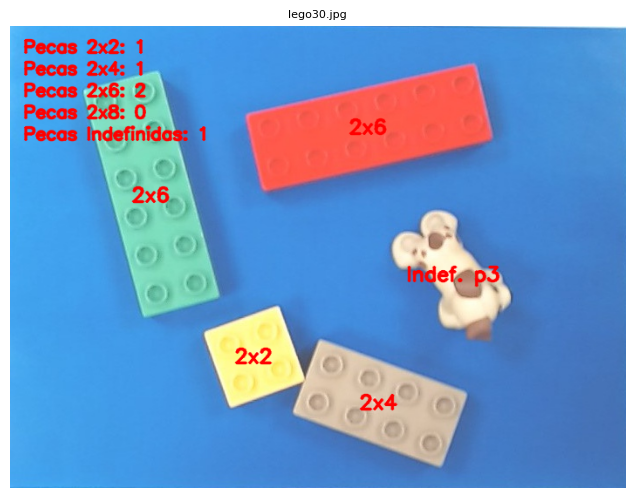

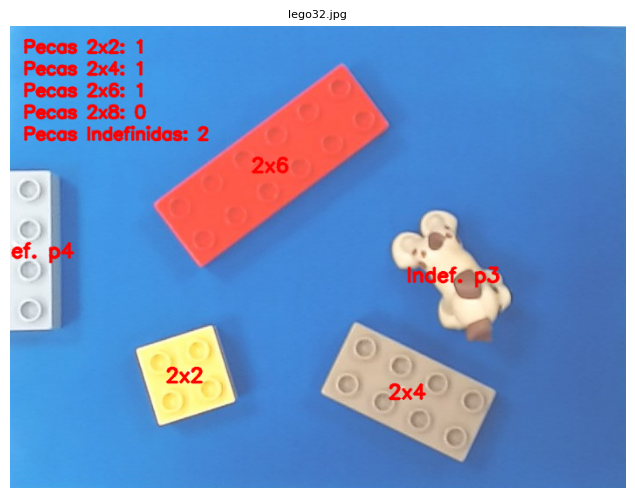

In [12]:
COR_TEXTO = (0, 0, 255) # Cor do texto 

imagens_classificadas = [] # array que guarda as imagens classificadas

for i, img in enumerate(imagens_melhoradas): 

    # Dicionário que armazena a contagem dos vários tipos de contador para as peças de Lego disponíveis
    contagem = {"2x2": 0, "2x4": 0, "2x6": 0, "2x8": 0, "Indefinidas": 0}

    h_img, w_img = img.shape # obter dimensões da imagem
    contornos, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) # encontrar os componentes conexos

    # Queremos usar as imagens originais pois são estas que serão classificadas
    base = cv2.imread(imagens[i])
    if base is None:
        print(f"Erro ao carregar: {imagens[i]}")
        
    # Percorre todos os contornos encontrados
    for contorno_idx, contorno in enumerate(contornos): 
        x, y, w, h = cv2.boundingRect(contorno) # obtém o retângulo envolvente do contorno
        tolerancia_borda = 2 #pixeis
        
        toca_borda = (x <= tolerancia_borda or 
                      y <= tolerancia_borda or 
                      (x + w) >= (w_img - tolerancia_borda) or 
                      (y + h) >= (h_img - tolerancia_borda))
        
        label_texto = "" # texto a ser exibido para o contorno atual
        
        if toca_borda:
            label_texto = f"Indef. p{contorno_idx+1}" 
            contagem["Indefinidas"] += 1
        else:
            # chama a função novamente para verificar se a peça é válida (retangular)
            is_rect, area, altura = isRectangle(contorno) 

            if is_rect: # se for uma peça válida vai etiquetar com algum tipo de 2xN
                tipo_peca = None # Começa como indefinida

                # Criamos intervalos para cada tipo de peça de acordo com a altura e a área               
                if (min_altura_2x2 <= altura <= max_altura_2x2 and 
                    min_area_2x2 <= area <= max_area_2x2):
                    tipo_peca = "2x2" 
                    contagem["2x2"] += 1 
                
                elif (min_altura_2x4 <= altura <= max_altura_2x4 and
                      min_area_2x4 <= area <= max_area_2x4):
                    tipo_peca = "2x4"
                    contagem["2x4"] += 1
                    
                elif (min_altura_2x6 <= altura <= max_altura_2x6 and
                      min_area_2x6 <= area <= max_area_2x6):
                    tipo_peca = "2x6"
                    contagem["2x6"] += 1

                elif (min_altura_2x8 <= altura <= max_altura_2x8 and
                      min_area_2x8 <= area <= max_area_2x8):
                    tipo_peca = "2x8"
                    contagem["2x8"] += 1

                # Se um tipo foi identificado, usa-o como rótulo
                if tipo_peca:
                    label_texto = tipo_peca
                else: 
                    # É um retângulo, mas não bateu em nenhum range
                    label_texto = f"Indef. p{contorno_idx+1}"
                    contagem["Indefinidas"] += 1
            else: 
                # Não é retangular
                label_texto = f"Indef. p{contorno_idx+1}"
                contagem["Indefinidas"] += 1

        
        font_scale = max(0.5, min(w_img, h_img) / 700.0) 
        
        text_size, _ = cv2.getTextSize(label_texto, TEXT_FONT, font_scale, 2)

        # Momentos para calcular o centróide do contorno
        M = cv2.moments(contorno) 
        if M['m00'] != 0:
            cx = int(M['m10'] / M['m00'])
            cy = int(M['m01'] / M['m00'])
            text_pos = (cx - text_size[0] // 2, cy + text_size[1] // 2)
        else: 
            x_rect, y_rect, bw, bh = cv2.boundingRect(contorno)
            text_pos = (x_rect + (bw - text_size[0]) // 2, y_rect + (bh + text_size[1]) // 2)

        # Escreve o tipo de peça 2xN ou Indefinida no centro da peça
        cv2.putText(base, label_texto, text_pos, TEXT_FONT, font_scale, COR_TEXTO, 2, cv2.LINE_AA)

    # Escreve no canto superior esquerdo o resumo da contagem efetuada em cada imagem
    informacoes = [
        f"Pecas 2x2: {contagem['2x2']}",
        f"Pecas 2x4: {contagem['2x4']}",
        f"Pecas 2x6: {contagem['2x6']}",
        f"Pecas 2x8: {contagem['2x8']}",
        f"Pecas Indefinidas: {contagem['Indefinidas']}"
    ]

    informacoes_posicao_y = 30 
    altura_linha = 25
    informacoes_font_scale = max(0.6, min(w_img, h_img) / 800.0)

    #Percorre as linhas de informação e escreve em cada imagem
    for numero_linha, texto_linha in enumerate(informacoes):
        posicao_linha = (15, informacoes_posicao_y + (numero_linha * altura_linha))
        cv2.putText(base, texto_linha, posicao_linha, TEXT_FONT, informacoes_font_scale, COR_TEXTO, 2, cv2.LINE_AA)

    imagens_classificadas.append(base)

# Mostrar imagens
for i, img in enumerate(imagens_classificadas):
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(os.path.basename(imagens[i]), fontsize=8)
    plt.axis('off')
    plt.show()

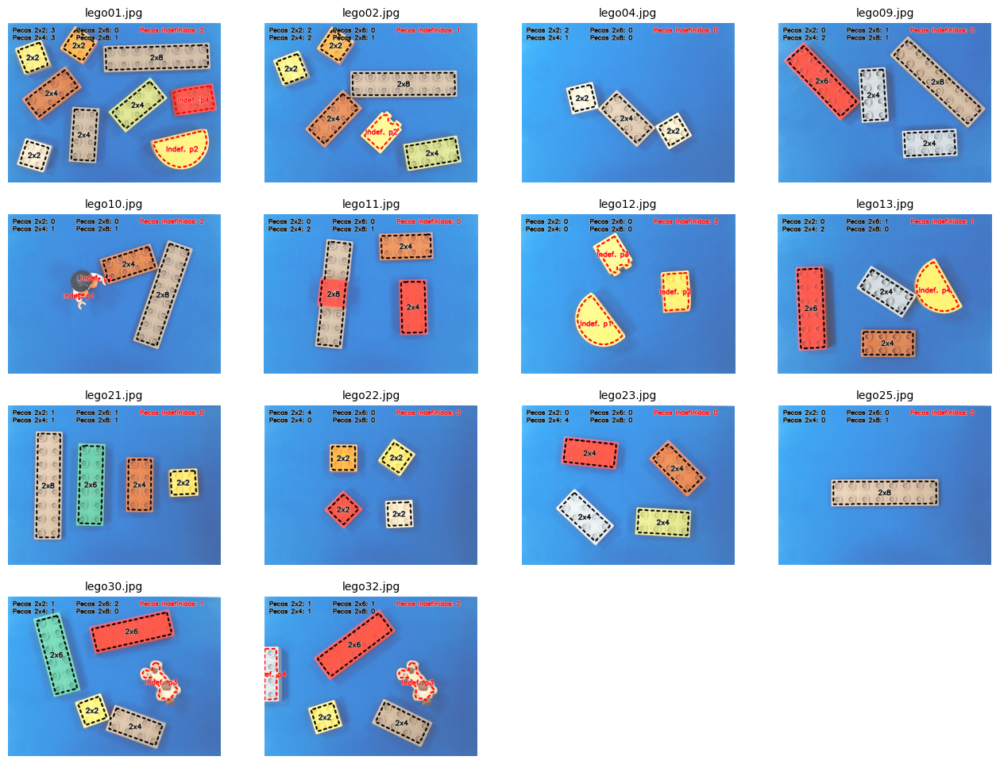

In [16]:
# Demonstracao final
TEXT_FONT = cv2.FONT_HERSHEY_SIMPLEX

# Definimos as cores. Preto para peças válidas, Vermelho para indefinidas
COR_VALIDA = (0, 0, 0)
COR_INDEFINIDA = (0, 0, 255)

def draw_dashed_contour(img, contour, color, thickness=2, dash_length=15):
    pts = contour.reshape(-1, 2)
    dist = 0
    for i in range(len(pts)):
        p1 = pts[i]
        p2 = pts[(i+1)%len(pts)]
        d = np.linalg.norm(p1 - p2)
        if d == 0: continue
        
        v = (p2 - p1) / d
        curr_d = 0
        while curr_d < d:
            step = min(dash_length - (dist % dash_length), d - curr_d)
            if int(dist // dash_length) % 2 == 0:
                start_pt = p1 + v * curr_d
                end_pt = p1 + v * (curr_d + step)
                cv2.line(img, (int(start_pt[0]), int(start_pt[1])), (int(end_pt[0]), int(end_pt[1])), color, thickness, cv2.LINE_AA)
            curr_d += step
            dist += step

def put_text_with_outline(img, text, pos, font_scale, color, thickness):
    # Desenha o contorno do texto a branco para destacar no fundo (outline)
    cv2.putText(img, text, pos, TEXT_FONT, font_scale, (255, 255, 255), thickness + 2, cv2.LINE_AA)
    # Desenha o texto principal por cima
    cv2.putText(img, text, pos, TEXT_FONT, font_scale, color, thickness, cv2.LINE_AA)

imagens_demonstracao = []
titulos_demonstracao = []

for i, img in enumerate(imagens_melhoradas): 
    contagem = {"2x2": 0, "2x4": 0, "2x6": 0, "2x8": 0, "Indefinidas": 0}
    h_img, w_img = img.shape
    contornos, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    base = cv2.imread(imagens[i])
    if base is None:
        continue
        
    for contorno_idx, contorno in enumerate(contornos): 
        x, y, w, h = cv2.boundingRect(contorno)
        tolerancia_borda = 2
        
        toca_borda = (x <= tolerancia_borda or 
                      y <= tolerancia_borda or 
                      (x + w) >= (w_img - tolerancia_borda) or 
                      (y + h) >= (h_img - tolerancia_borda))
        
        label_texto = ""
        cor_atual = COR_INDEFINIDA
        
        if toca_borda:
            label_texto = f"Indef. p{contorno_idx+1}" 
            contagem["Indefinidas"] += 1
            cor_atual = COR_INDEFINIDA
        else:
            is_rect, area, altura = isRectangle(contorno) 
            if is_rect:
                tipo_peca = None
                if (min_altura_2x2 <= altura <= max_altura_2x2 and min_area_2x2 <= area <= max_area_2x2):
                    tipo_peca = "2x2" 
                elif (min_altura_2x4 <= altura <= max_altura_2x4 and min_area_2x4 <= area <= max_area_2x4):
                    tipo_peca = "2x4"
                elif (min_altura_2x6 <= altura <= max_altura_2x6 and min_area_2x6 <= area <= max_area_2x6):
                    tipo_peca = "2x6"
                elif (min_altura_2x8 <= altura <= max_altura_2x8 and min_area_2x8 <= area <= max_area_2x8):
                    tipo_peca = "2x8"

                if tipo_peca:
                    label_texto = tipo_peca
                    contagem[tipo_peca] += 1
                    cor_atual = COR_VALIDA
                else: 
                    label_texto = f"Indef. p{contorno_idx+1}"
                    contagem["Indefinidas"] += 1
                    cor_atual = COR_INDEFINIDA
            else: 
                label_texto = f"Indef. p{contorno_idx+1}"
                contagem["Indefinidas"] += 1
                cor_atual = COR_INDEFINIDA

        # Desenha o tracejado com a cor respetiva (preto ou vermelho)
        draw_dashed_contour(base, contorno, cor_atual, 3, 10)

        font_scale = max(0.5, min(w_img, h_img) / 700.0) 
        text_size, _ = cv2.getTextSize(label_texto, TEXT_FONT, font_scale, 2)

        M = cv2.moments(contorno) 
        if M['m00'] != 0:
            cx = int(M['m10'] / M['m00'])
            cy = int(M['m01'] / M['m00'])
            text_pos = (cx - text_size[0] // 2, cy + text_size[1] // 2)
        else: 
            x_rect, y_rect, bw, bh = cv2.boundingRect(contorno)
            text_pos = (x_rect + (bw - text_size[0]) // 2, y_rect + (bh + text_size[1]) // 2)

        # Imprime o nome da peça (preto ou vermelho) com a sombra branca
        put_text_with_outline(base, label_texto, text_pos, font_scale, cor_atual, 2)

    # Escreve o painel de contagens (Legenda)
    chaves_contagem = ["2x2", "2x4", "2x6", "2x8", "Indefinidas"]
    informacoes_font_scale = max(0.6, min(w_img, h_img) / 800.0)
    
    col_width = int(w_img * 0.30) # Largura de cada coluna na legenda (30% da imagem)
    altura_linha = 25 # Espaçamento vertical

    for idx, chave in enumerate(chaves_contagem):
        col = idx // 2 # 2 linhas por coluna (índice 0 e 1 = col 0; índice 2 e 3 = col 1; etc)
        row = idx % 2
        
        x = 15 + col * col_width
        y = 30 + row * altura_linha
        
        texto_linha = f"Pecas {chave}: {contagem[chave]}"
        
        # Cor da legenda: vermelho se for Indefinidas, senão preto
        cor_legenda = COR_INDEFINIDA if chave == "Indefinidas" else COR_VALIDA
        
        put_text_with_outline(base, texto_linha, (x, y), informacoes_font_scale, cor_legenda, 2)

    imagens_demonstracao.append(base)
    titulos_demonstracao.append(os.path.basename(imagens[i]))

# Mostrar imagens todas lado a lado
num_imgs = len(imagens_demonstracao)
cols = 4 
rows = (num_imgs + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
if rows * cols > 1:
    axes = axes.flatten()
else:
    axes = [axes]

for i, img in enumerate(imagens_demonstracao):
    axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[i].set_title(titulos_demonstracao[i], fontsize=10)
    axes[i].axis('off')
    
for j in range(len(imagens_demonstracao), len(axes)):
    axes[j].axis('off')

plt.show()


Podemos observar que o processo de classificação foi bem sucedido, com todas as peças a serem corretamente identificadas e rotuladas de acordo com as suas dimensões. 

<center><h2><b>Conclusão</b></h2></center>

Após toda a implementação do trabalho, sentimos que a fase com maiores dificuldades apresentadas foi no pré‑processamento das imagens, ao garantir que todas as peças ficassem corretamente segmentadas na binarização. Revelou‑se desafiante devido à semelhança de cor de algumas peças com o fundo. A estratégia que adotámos, a recoloração das peças esverdeadas através de uma máscara, permitiu estabilizar a segmentação. Também no melhoramento morfológico houve qalgumas dificuldades na escolha dos parâmetros dos kernels (forma e tamanho). O equilíbrio entre separar peças coladas (erosão mais forte) e preservar o seu contorno (dilatação adequada) exigiu afinação até obter imagens limpas e consistentes.

Em suma, a abordagem é simples e eficaz no conjunto de treino fornecido pelo docente, demonstrando assim a utilidade da biblioteca OpenCV para problemas de contagem e classificação.

<center><h2><b>Bibliografia</b></h2></center>

Jorge, Pedro, Documentação da unidade curricular 2025-2026, Lisboa: ISEL, 2025

https://docs.opencv.org/4.x/ - Documentação oficial da biblioteca OpenCV
